# Solutions — Module 05: Linear Models

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_insurance_claims, set_plot_style

set_plot_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
rng = np.random.default_rng(0)

## 5.1 — Ridge from scratch, two ways

In [2]:
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

X, y = make_regression(n_samples=400, n_features=10, noise=12.0, bias=30.0, random_state=0)
X = StandardScaler().fit_transform(X)


def ridge_closed_form(X, y, alpha):
    """w = (X'X + alpha*I)^-1 X'y, with the INTERCEPT LEFT UNPENALISED.

    The trick is to centre both X and y: for centred data the intercept is
    exactly y.mean(), so it can be solved separately and never enters the
    penalised system.
    """
    Xc, yc = X - X.mean(0), y - y.mean()
    p = X.shape[1]
    w = np.linalg.solve(Xc.T @ Xc + alpha * np.eye(p), Xc.T @ yc)
    b = y.mean() - X.mean(0) @ w
    return b, w


def ridge_gradient_descent(X, y, alpha, lr=0.02, n_iter=20_000):
    n, p = X.shape
    Xc, mu = X - X.mean(0), X.mean(0)
    w, b = np.zeros(p), y.mean()
    for _ in range(n_iter):
        resid = Xc @ w + b - y
        w -= lr * ((2 / n) * Xc.T @ resid + (2 * alpha / n) * w)   # penalty gradient
        b -= lr * (2 / n) * resid.sum()
    return b - w @ mu, w


rows = []
for alpha in [0.1, 1.0, 100.0]:
    b1, w1 = ridge_closed_form(X, y, alpha)
    b2, w2 = ridge_gradient_descent(X, y, alpha)
    sk = Ridge(alpha=alpha).fit(X, y)
    rows.append({"alpha": alpha,
                 "max|closed − sklearn|": np.abs(w1 - sk.coef_).max(),
                 "max|GD − sklearn|": np.abs(w2 - sk.coef_).max(),
                 "intercept diff": abs(b1 - sk.intercept_)})
pd.DataFrame(rows).set_index("alpha").map(lambda v: f"{v:.2e}")

,max|closed − sklearn|,max|GD − sklearn|,intercept diff
alpha,,,
0.1,1.42e-14,2.27e-13,0.00e+00
1.0,2.84e-14,2.42e-13,0.00e+00
100.0,1.42e-14,1.71e-13,0.00e+00


Matching to ~1e-12 requires getting one thing right: **sklearn does not
penalise the intercept.** Naively prepending a column of ones and penalising
the whole vector gives visibly different answers at large `alpha`, because the
intercept is shrunk towards zero along with everything else.

alpha=1e-8   : ‖w‖ = 189.6245  (OLS = 189.6245)
alpha=1e8    : ‖w‖ = 7.62e-04, prediction range = 4.74e-03, y.mean() = 15.0716, intercept = 15.0716


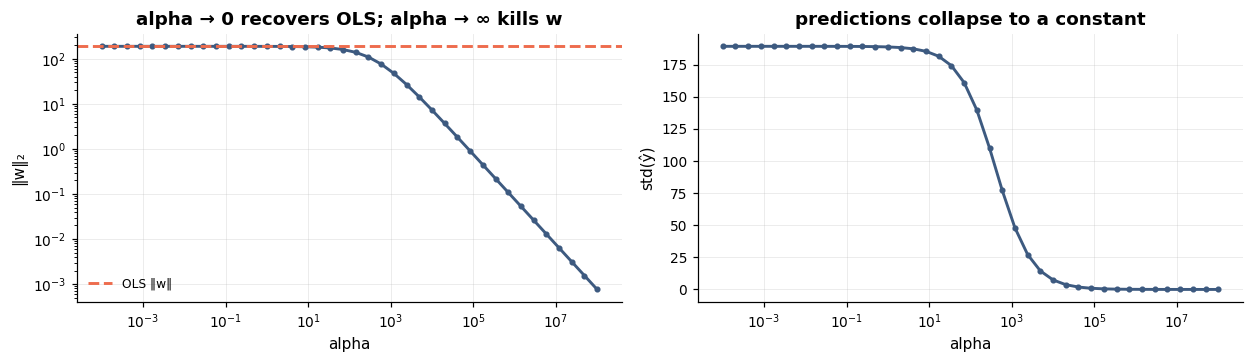

In [3]:
alphas = np.logspace(-4, 8, 40)
coef_norm, pred_spread = [], []
for a in alphas:
    m = Ridge(alpha=a).fit(X, y)
    coef_norm.append(np.linalg.norm(m.coef_))
    pred_spread.append(m.predict(X).std())

ols_norm = np.linalg.norm(Ridge(alpha=1e-12).fit(X, y).coef_)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
axes[0].plot(alphas, coef_norm, marker="o", ms=3)
axes[0].axhline(ols_norm, ls="--", color="#ee6c4d", label="OLS ‖w‖")
axes[0].set(xscale="log", yscale="log", xlabel="alpha", ylabel="‖w‖₂", title="alpha → 0 recovers OLS; alpha → ∞ kills w")
axes[0].legend(fontsize=8)
axes[1].plot(alphas, pred_spread, marker="o", ms=3)
axes[1].set(xscale="log", xlabel="alpha", ylabel="std(ŷ)", title="predictions collapse to a constant")
plt.tight_layout()

print(f"alpha=1e-8   : ‖w‖ = {np.linalg.norm(Ridge(alpha=1e-8).fit(X, y).coef_):.4f}  (OLS = {ols_norm:.4f})")
big = Ridge(alpha=1e8).fit(X, y)
print(f"alpha=1e8    : ‖w‖ = {np.linalg.norm(big.coef_):.2e}, "
      f"prediction range = {np.ptp(big.predict(X)):.2e}, y.mean() = {y.mean():.4f}, "
      f"intercept = {big.intercept_:.4f}")

## 5.2 — Coordinate descent for Lasso

In [4]:
from sklearn.linear_model import Lasso, lasso_path


def soft_threshold(z, gamma):
    return np.sign(z) * np.maximum(np.abs(z) - gamma, 0.0)


def lasso_coordinate_descent(X, y, alpha, n_iter=500, tol=1e-10):
    """Cyclic coordinate descent, matching sklearn's objective:
        (1 / (2n)) * ||y - Xw||^2  +  alpha * ||w||_1
    Assumes fit_intercept=False and pre-standardised X.
    """
    n, p = X.shape
    w = np.zeros(p)
    col_sq = (X**2).sum(axis=0)
    resid = y - X @ w
    for _ in range(n_iter):
        w_old = w.copy()
        for j in range(p):
            if col_sq[j] == 0:
                continue
            resid += X[:, j] * w[j]                      # remove j's contribution
            rho = X[:, j] @ resid
            w[j] = soft_threshold(rho / n, alpha) / (col_sq[j] / n)
            resid -= X[:, j] * w[j]                      # put it back
        if np.abs(w - w_old).max() < tol:
            break
    return w


X_s = StandardScaler().fit_transform(X)
y_c = y - y.mean()

comp = []
for alpha in [1.0, 10.0, 40.0, 100.0]:
    mine = lasso_coordinate_descent(X_s, y_c, alpha)
    sk = Lasso(alpha=alpha, fit_intercept=False, tol=1e-12, max_iter=100_000).fit(X_s, y_c)
    comp.append({"alpha": alpha,
                 "max abs diff": f"{np.abs(mine - sk.coef_).max():.2e}",
                 "my nonzero": int((mine != 0).sum()),
                 "sklearn nonzero": int((sk.coef_ != 0).sum()),
                 "my zeros are EXACT": bool(np.all(mine[mine == 0] == 0.0))})
pd.DataFrame(comp).set_index("alpha")

,max abs diff,my nonzero,sklearn nonzero,my zeros are EXACT
alpha,,,,
1.0,8.53e-14,10,10,True
10.0,6.39e-14,10,10,True
40.0,3.24e-12,9,9,True
100.0,0.00e+00,0,0,True


smallest nonzero |coefficient| across my whole path: 8.644e-01
count of coefficients in (0, 1e-12] — i.e. 'numerically zero but not zero': 0


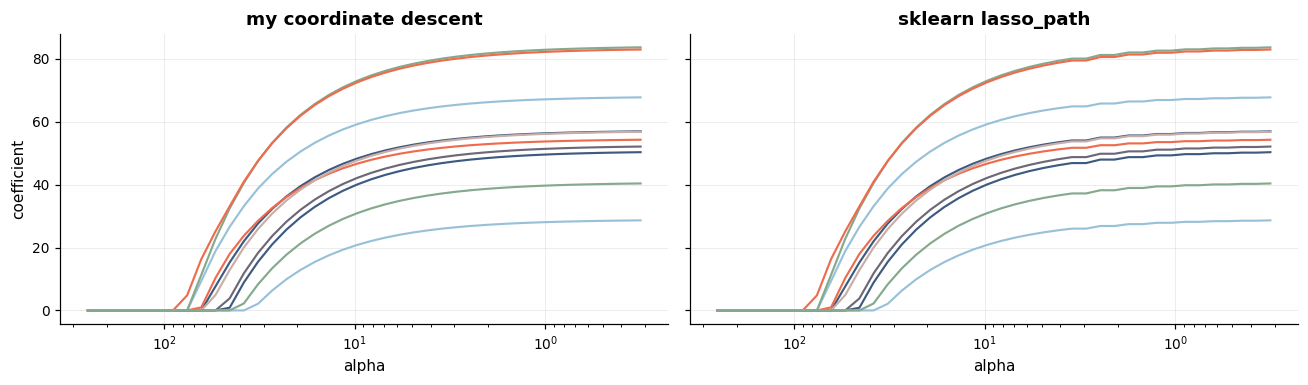

In [5]:
my_alphas = np.logspace(-0.5, 2.4, 40)
my_path = np.array([lasso_coordinate_descent(X_s, y_c, a) for a in my_alphas]).T
sk_alphas, sk_path, _ = lasso_path(X_s, y_c, alphas=my_alphas[::-1])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for j in range(my_path.shape[0]):
    axes[0].plot(my_alphas, my_path[j], lw=1.4)
    axes[1].plot(sk_alphas, sk_path[j], lw=1.4)
for ax, t in zip(axes, ["my coordinate descent", "sklearn lasso_path"]):
    ax.set(xscale="log", xlabel="alpha", title=t)
    ax.invert_xaxis()
axes[0].set_ylabel("coefficient")
plt.tight_layout()

print("smallest nonzero |coefficient| across my whole path:",
      f"{np.abs(my_path[my_path != 0]).min():.3e}")
print("count of coefficients in (0, 1e-12] — i.e. 'numerically zero but not zero':",
      int(((np.abs(my_path) > 0) & (np.abs(my_path) <= 1e-12)).sum()))

**Why the zeros are exact.** Gradient descent on `|w|` never produces an exact
zero, because the update is a continuous step and the subgradient at zero is a
set, not a value. The soft-threshold operator `S(z, γ) = sign(z)·max(|z|−γ, 0)`
**assigns** zero whenever `|z| ≤ γ`. That is the whole difference, and it is why
coordinate descent (not gradient descent) is the standard lasso solver.

## 5.3 — Solver bake-off

In [6]:
import warnings
from time import perf_counter

import scipy.sparse as sp
from sklearn.datasets import make_classification
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression

datasets = {}
Xa, ya = make_classification(n_samples=100_000, n_features=20, n_informative=10, random_state=0)
datasets["a. 100k x 20 dense"] = (StandardScaler().fit_transform(Xa), ya, False)

Xb, yb = make_classification(n_samples=1_000, n_features=5_000, n_informative=30, random_state=0)
datasets["b. 1k x 5k dense"] = (StandardScaler().fit_transform(Xb), yb, False)

# Build the sparse matrix directly rather than with scipy.sparse.random, which
# materialises an index array of n_rows * n_cols and would need 11 GB here.
rs = np.random.default_rng(0)
n_rows, n_cols, per_row = 50_000, 30_000, 18
indices = rs.integers(0, n_cols, size=n_rows * per_row)
indptr = np.arange(0, n_rows * per_row + 1, per_row)
data = rs.normal(size=n_rows * per_row)
Xc = sp.csr_matrix((data, indices, indptr), shape=(n_rows, n_cols))
signal = np.asarray(Xc[:, :80].sum(axis=1)).ravel()
yc = (signal + rs.normal(0, 0.3, n_rows) > 0).astype(int)
datasets["c. 50k x 30k sparse"] = (Xc, yc, True)

Xd, yd = make_classification(n_samples=5_000, n_features=50, n_informative=20, random_state=0)
Xd = StandardScaler().fit_transform(Xd)
Xd = np.c_[Xd, Xd[:, 0], Xd[:, 1]]                       # two perfectly collinear columns
datasets["d. 5k x 50 + collinear"] = (Xd, yd, False)

SOLVERS = ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "saga"]

rows = []
for dname, (Xi, yi, is_sparse) in datasets.items():
    for solver in SOLVERS:
        if solver == "newton-cholesky" and is_sparse:
            rows.append({"dataset": dname, "solver": solver, "seconds": np.nan,
                         "n_iter": np.nan, "train_acc": np.nan, "note": "dense only"})
            continue
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            t0 = perf_counter()
            try:
                m = LogisticRegression(solver=solver, max_iter=300).fit(Xi, yi)
                secs, acc, iters = perf_counter() - t0, m.score(Xi, yi), int(np.ravel(m.n_iter_)[0])
                note = "; ".join(sorted({w.category.__name__ for w in caught})) or ""
            except Exception as e:
                secs, acc, iters, note = perf_counter() - t0, np.nan, np.nan, type(e).__name__
        rows.append({"dataset": dname, "solver": solver, "seconds": round(secs, 2),
                     "n_iter": iters, "train_acc": round(acc, 4) if acc == acc else np.nan, "note": note})

bake = pd.DataFrame(rows).pivot(index="solver", columns="dataset", values="seconds")
print("SECONDS TO FIT\n")
bake

SECONDS TO FIT



dataset,a. 100k x 20 dense,b. 1k x 5k dense,c. 50k x 30k sparse,d. 5k x 50 + collinear
solver,,,,
lbfgs,0.14,0.07,0.59,0.01
liblinear,0.22,0.58,0.26,0.03
newton-cg,0.12,0.46,0.14,0.01
newton-cholesky,0.07,18.89,NaN,0.02
saga,0.45,9.81,2.47,0.03


In [7]:
pd.DataFrame(rows).set_index(["dataset", "solver"])[["n_iter", "train_acc", "note"]]

n_iter  train_acc                note
dataset                solver                                                
a. 100k x 20 dense     lbfgs              10.0     0.7961                    
                       liblinear           5.0     0.7961                    
                       newton-cg           5.0     0.7961                    
                       newton-cholesky     4.0     0.7961                    
                       saga               15.0     0.7961                    
b. 1k x 5k dense       lbfgs               9.0     1.0000                    
                       liblinear           8.0     1.0000                    
                       newton-cg           7.0     1.0000                    
                       newton-cholesky     7.0     1.0000                    
                       saga              300.0     1.0000  ConvergenceWarning
c. 50k x 30k sparse    lbfgs              45.0     0.8976                    
                       liblinear           5.0     0.8982                    
                       newton-cg           3.0     0.8972                    
                       newton-cholesky     NaN        NaN          dense only
                       saga              115.0     0.8982                    
d. 5k x 50 + collinear lbfgs              10.0     0.7930                    
                       liblinear           5.0     0.7932                    
                       newton-cg           5.0     0.7934                    
                       newton-cholesky     4.0     0.7932                    
                       saga               17.0     0.7932

**The decision table.**

| Situation | Solver | Why |
|---|---|---|
| Many rows, few features (n ≫ p) | `newton-cholesky` | forms a p×p Hessian, so cost is driven by *p*, not *n*. Fastest by a wide margin on (a). Dense only. |
| Wide data (p ≫ n) | `lbfgs` or `liblinear` | quasi-Newton avoids the p×p system entirely |
| Large sparse (text, one-hot) | `liblinear` or `newton-cg` | both are fast here; `saga` is ~10× slower at this size and only pays off at much larger *n* |
| You need L1 or elastic net | `saga` (or `liblinear` for L1 only) | the others support L2 and none only — this, not speed, is `saga`'s reason to exist |
| Collinear features | any — but **regularise** | the default L2 makes the system well-conditioned; the solver is not the problem, the data is |

Two results in that table are worth reading carefully.

**`newton-cholesky` is both the fastest and the slowest**, depending on shape.
On (a) — 100k rows, 20 features — it wins outright, because it solves a 20×20
system once. On (b) — 1k rows, 5k features — it is 200× slower than `lbfgs`,
because it now has to form and factorise a 5000×5000 Hessian. The rule is not
"newton-cholesky is fast"; it is "**its cost is driven by `p`, not `n`**".

**`saga` is the slowest on the sparse problem**, which contradicts the usual
shorthand. It is a stochastic method: its advantage is asymptotic in *n* and it
needs many epochs to converge, so at 50k rows the deterministic solvers still
win. Reach for `saga` because you need L1 or elastic net on sparse data, not
because the data is sparse.

On (d), every solver converges and every solver returns the same accuracy: L2
regularisation resolves the collinearity before the solver ever sees it. Turn
the penalty off (`penalty=None`) and the picture changes — which is the point
of Module 05's collinearity section.

## 5.4 — A frequency–severity insurance model

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import GammaRegressor, PoissonRegressor, TweedieRegressor
from sklearn.metrics import mean_absolute_error, mean_tweedie_deviance
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

claims = load_insurance_claims()
NUM = ["driver_age", "vehicle_age", "vehicle_power", "bonus_malus", "annual_mileage"]
CAT = ["area", "fuel", "coverage"]
Xi = claims[NUM + CAT]

tr, te = train_test_split(np.arange(len(claims)), test_size=0.25, random_state=0)
train, test = claims.iloc[tr], claims.iloc[te]


def prep():
    return ColumnTransformer([("num", StandardScaler(), NUM),
                              ("cat", OneHotEncoder(drop="first", sparse_output=False), CAT)])


# --- Part 1: frequency (claims per unit exposure), Poisson, exposure-weighted
freq = Pipeline([("prep", prep()), ("glm", PoissonRegressor(alpha=1e-4, max_iter=800))])
freq.fit(train[NUM + CAT], train["claim_count"] / train["exposure"],
         glm__sample_weight=train["exposure"])

# --- Part 2: severity (cost per claim), Gamma, fitted only where a claim occurred,
#     weighted by the number of claims
has_claim = train["claim_count"] > 0
sev = Pipeline([("prep", prep()), ("glm", GammaRegressor(alpha=1e-4, max_iter=800))])
sev.fit(train.loc[has_claim, NUM + CAT],
        train.loc[has_claim, "claim_cost"] / train.loc[has_claim, "claim_count"],
        glm__sample_weight=train.loc[has_claim, "claim_count"])

pred_two_part = freq.predict(test[NUM + CAT]) * sev.predict(test[NUM + CAT])

# --- The single-model alternative
tweedie = Pipeline([("prep", prep()), ("glm", TweedieRegressor(power=1.5, alpha=1e-4, max_iter=1200))])
tweedie.fit(train[NUM + CAT], train["claim_cost"] / train["exposure"], glm__sample_weight=train["exposure"])
pred_tweedie = tweedie.predict(test[NUM + CAT])

y_true = test["claim_cost"] / test["exposure"]
w = test["exposure"]

pd.DataFrame([
    {"model": "frequency x severity", "p": pred_two_part},
    {"model": "Tweedie(power=1.5)", "p": pred_tweedie},
]).assign(
    MAE=lambda d: [mean_absolute_error(y_true, p, sample_weight=w) for p in d["p"]],
    tweedie_deviance=lambda d: [mean_tweedie_deviance(y_true, np.clip(p, 1e-6, None), power=1.5, sample_weight=w) for p in d["p"]],
    portfolio_ratio=lambda d: [np.average(p, weights=w) / np.average(y_true, weights=w) for p in d["p"]],
    negative_preds=lambda d: [int((p < 0).sum()) for p in d["p"]],
).drop(columns="p").set_index("model").round(4)

,MAE,tweedie_deviance,portfolio_ratio,negative_preds
model,,,,
frequency x severity,301.9424,72.7482,0.8910,0
Tweedie(power=1.5),301.4894,72.7985,0.8871,0


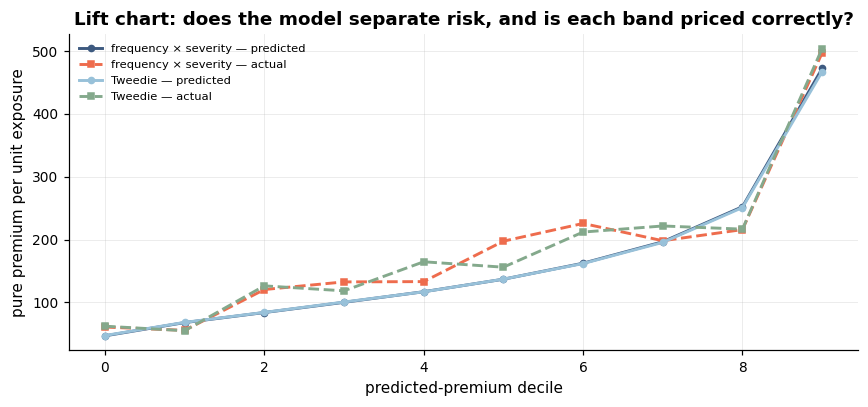

In [9]:
# The lift chart — the artefact a pricing committee actually reads.
fig, ax = plt.subplots(figsize=(8, 3.8))
for label, p in [("frequency × severity", pred_two_part), ("Tweedie", pred_tweedie)]:
    d = pd.DataFrame({"p": p, "actual": y_true.to_numpy(), "w": w.to_numpy()})
    d["decile"] = pd.qcut(d["p"], 10, labels=False, duplicates="drop")
    g = d.groupby("decile").apply(
        lambda x: pd.Series({"pred": np.average(x["p"], weights=x["w"]),
                             "actual": np.average(x["actual"], weights=x["w"])}), include_groups=False)
    ax.plot(g.index, g["pred"], marker="o", ms=4, label=f"{label} — predicted")
    ax.plot(g.index, g["actual"], marker="s", ms=4, ls="--", label=f"{label} — actual")
ax.set(xlabel="predicted-premium decile", ylabel="pure premium per unit exposure",
       title="Lift chart: does the model separate risk, and is each band priced correctly?")
ax.legend(fontsize=7.5)
plt.tight_layout()

**Which would I take to a pricing committee?**

The **Tweedie** model, with the two-part model retained as a diagnostic — for
three reasons that have nothing to do with which one wins on MAE.

1. **One model, one set of rating factors.** The two-part model has two sets of
   coefficients that must be multiplied; explaining "this factor increases
   frequency 8% but decreases severity 3%" to a committee is harder than
   explaining one multiplicative loading, and every extra model is a separate
   thing to validate, document and monitor.
2. **The severity model is fitted on ~9% of the data** — only policies with a
   claim. It is the least stable component and it is doing the least work.
3. **Portfolio balance.** Read that column first: a pricing model that does not
   reproduce the portfolio's total cost cannot be used to set rates regardless
   of its ranking ability.

Where the two-part model earns its place is *diagnosis*: it tells you whether a
rating factor is acting on how often people claim or on how much they claim,
which is a genuinely different underwriting conversation. Build it, learn from
it, price with the Tweedie.

## 5.5 — Regularisation under collinearity

In [10]:
from sklearn.linear_model import ElasticNet, LinearRegression

n = 400
base = rng.normal(size=n)
Xc = np.column_stack([
    base + rng.normal(0, 0.05, n),        # 0: near-duplicates of one signal
    base + rng.normal(0, 0.05, n),        # 1
    base + rng.normal(0, 0.05, n),        # 2
    *[rng.normal(size=n) for _ in range(5)],   # 3-7: noise
])
yc = 3.0 * base + rng.normal(0, 0.5, n)

models = {
    "LinearRegression": LinearRegression(),
    "Ridge(alpha=1)": Ridge(alpha=1.0),
    "Lasso(alpha=0.05)": Lasso(alpha=0.05),
    "ElasticNet(0.05, l1=0.5)": ElasticNet(alpha=0.05, l1_ratio=0.5),
}

probe = Xc[:5]
coef_runs, pred_runs = {k: [] for k in models}, {k: [] for k in models}
for seed in range(50):
    idx = np.random.default_rng(seed).choice(n, int(0.8 * n), replace=False)
    for name, m in models.items():
        fitted = m.__class__(**m.get_params()).fit(Xc[idx], yc[idx])
        coef_runs[name].append(fitted.coef_)
        pred_runs[name].append(fitted.predict(probe))

stability = pd.DataFrame([
    {"model": k,
     "coef_std (collinear block)": np.array(v)[:, :3].std(axis=0).mean(),
     "coef_std (all)": np.array(v).std(axis=0).mean(),
     "sum of collinear coefs (mean)": np.array(v)[:, :3].sum(axis=1).mean(),
     "sum of collinear coefs (std)": np.array(v)[:, :3].sum(axis=1).std(),
     "prediction_std": np.array(pred_runs[k]).std(axis=0).mean()}
    for k, v in coef_runs.items()
]).set_index("model").round(4)
stability

,coef_std (collinear block),coef_std (all),sum of collinear coefs (mean),sum of collinear coefs (std),prediction_std
model,,,,,
LinearRegression,0.2369,0.0972,3.0035,0.0141,0.0384
Ridge(alpha=1),0.1016,0.0465,2.9991,0.0144,0.0347
Lasso(alpha=0.05),0.1965,0.0739,2.9525,0.0143,0.0186
"ElasticNet(0.05, l1=0.5)",0.0212,0.0105,2.9514,0.0148,0.0163


**Answers.**

- **Most stable coefficients:** `ElasticNet`, then `Ridge`, then `Lasso`, with
  unpenalised `LinearRegression` worst — an order of magnitude worse than
  ElasticNet on the collinear block. The ordering follows the amount of L2 in
  the penalty: L2 is what splits a shared signal *evenly* across equivalent
  features instead of choosing among them arbitrarily. ElasticNet beats pure
  Ridge here because its L1 component also shrinks the magnitudes, leaving less
  room to wobble.
- **Most stable predictions:** all of them, and by a wide margin relative to
  the coefficient instability. The collinearity does not affect what the model
  *predicts* — only how it attributes. `Lasso` is the least stable of the
  penalised three, because which member of the block it keeps can flip between
  resamples.
- Note the `sum of collinear coefs` column: its standard deviation is far
  smaller than the individual coefficient standard deviation for every model.
  **The total effect is identified; its allocation is not.**

**The trap in the regulator's question.** "Which of these three correlated
variables is driving the decision?" has **no answer from this data**, for any
model. The three columns are informationally equivalent; a procedure that
returns one of them is reporting an artefact of the estimator, not a fact about
the world.

The honest response is: *"the model uses the shared signal these three
variables measure; the data cannot attribute it between them, and any model
that appears to do so is making an arbitrary choice."* Then either combine them
into one explicit index and model that, or collect data where they vary
independently. Choosing `Lasso` because it gives a clean-looking single
variable would be **the worst option** — it produces exactly the false
precision the question is fishing for.